# PARTICIPANT 6

This script processes environmental monitoring data collected from various sources including Eltek, bathroom sensors, bedroom CO2 sensors, weather data, and noise sensors. The script cleans, merges, and calibrates this data to create a consolidated dataset. Additionally, it identifies and handles issues in the data (e.g., sensor errors) and prepares the data for further analysis.

**Key features:**
- Ingest and preprocess environmental data from multiple sources.
- Calibrate and baseline CO2 and noise data.
- Handle missing, infinite, and erroneous data points.
- Generate dictionaries categorizing data by room and type for analysis.

**Notes about campaign:**
1. Participant wrongly returned 4 sensors too early, so had to change over part way

**Notes about data/analysis:**
1. No internal sensors, so there might be instances where the occupancy algorithm predicts that the dwelling is unoccupied, as front door has opened, closed, opened closed and there has been no rise in CO2 between the closed and open. This doesnt mean it wasnt occupied.
2. Occupancy thresholds need refining.
3. No unoccupied times, not able to correct CO2
4. Campaign over most of winter and only a tiny amount of summer

## Import Packages and Functions

In [1]:
# -*- coding: utf-8 -*-
#!/usr/bin/python

import os

# run shared function notebooks to load all functions
%run functions.ipynb
%run plotting_functions.ipynb

Packages loaded.

All functions have been defined.


## Load Eltek Data

Load environmental data from the Eltek AQ110a sensor system.

**Sensor Configuration:**
- AQ110A EI130855 T-32656: Outside
- AQ110A EI130895 T-32672: Kitchen
- AQ110A EI130887 T-32658: Living Room
- GD47AC EI130994 T-36249: Main bedroom
- GD47AC EI130997 T-36244: Second bedroom

**Sensor IDs:** 32656, 32672, 32658, 36249, 36244

In [2]:
p6_eltek = ingest_aq110a(path = '../data/p6_north_london_semi/data_unprocessed/K01830-12194.csv'
                      , import_variables = ['','temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            , 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            , 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            ,'temperature', 'humidity', 'co2'
                                            ,'temperature', 'humidity', 'co2'
                                            ]
                      , column_names = ['external_temperature', 'external_humidity', 'external_co2', 'external_1um', 'external_25um', 'external_100um', 'external_airflow', 'external_no2', 'external_co1', 'external_voc',
                                        'kitchen_temperature', 'kitchen_humidity', 'kitchen_co2', 'kitchen_1um', 'kitchen_25um', 'kitchen_100um', 'kitchen_airflow', 'kitchen_no2', 'kitchen_co1', 'kitchen_voc',
                                        'living_temperature', 'living_humidity', 'living_co2', 'living_1um', 'living_25um', 'living_100um', 'living_airflow', 'living_no2', 'living_co1', 'living_voc',
                                        'bedroom1_temperature', 'bedroom1_humidity', 'bedroom1_co2',
                                        'bedroom2_temperature', 'bedroom2_humidity', 'bedroom2_co2'
                                        ]
                      , convert_no2 = True
                      , convert_co = True
                      , input_interpolate = True
                      , input_iterpolate_limit = 6
                      )

p6_eltek = p6_eltek.reset_index()
# delete external temp and rh
del p6_eltek['external_temperature']
del p6_eltek['external_humidity']

# baseline co1 and no2
aq110a_no2_co1_baseline (input_dataframe = p6_eltek
                             , input_percentile = 5)


---------------------------------------------
Ingesting AQ110a data from ../data/p6_north_london_semi/data_unprocessed/K01830-12194.csv


/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94811/1228987109.py:59: DtypeWarning: Columns (1,2,3,4,5,7,8,9,10,11,12,13,14,17,18,19,20,21,22,23,27,28,29,30,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  eltek = pd.read_csv(path, skiprows = 3) # ingest



Correction

-----------------------
32656_temperature
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_humidity
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_co2
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_1um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_25um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_100um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32656_airflow
baseline_correction

False


## Load Ground Floor Bathroom Data

Load gfbathroom temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments (first to last):**
- EI130530 (10065116): Bathroom 1 - 07/07/2021
- EI130481 (1074287): Bathroom 1 - 04/10/2021
- EI130556 (1092878): Bathroom 1 - NA
- EI130459 (1088090): Bathroom 1 - 23/02/2022

In [3]:
#### p6_gfbathroom - file 1
p6_gfbathroom_ieq_1 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/211022_EI130530.csv'
                      , 0
                      , ['date', 'time', 'gfbathroom_temperature', 'gfbathroom_humidity', 'gfbathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130530'
                      )

#### p6_gfbathroom - file 2
p6_gfbathroom_ieq_2 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/211206_EI130481.csv'
                      , 0
                      , ['date', 'time', 'gfbathroom_temperature', 'gfbathroom_humidity', 'gfbathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130481'
                      )

#### p6_gfbathroom - file 3
p6_gfbathroom_ieq_3 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/220308_EI130556.csv'
                      , 0
                      , ['date', 'time', 'gfbathroom_temperature', 'gfbathroom_humidity', 'gfbathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130556'
                      )

#### p6_gfbathroom - file 4
p6_gfbathroom_ieq_4 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/220422_EI130459.csv'
                      , 0
                      , ['date', 'time', 'gfbathroom_temperature', 'gfbathroom_humidity', 'gfbathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130459'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p6_north_london_semi/data_unprocessed/211022_EI130530.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 gfbathroom_temperature    0
gfbathroom_humidity       0
gfbathroom_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p6_north_london_semi/data_unprocessed/211206_EI130481.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 gfbathroom_temperature    0
gfbathroom_humidity       0
gfbath

## Join Ground Floor Bathroom Data

Concatenate gfbathroom data from different time periods:
- File 1: beginning to 2021-10-16 21:00
- File 2: 2021-10-16 21:05 to 2021-12-02 00:00
- File 3: 2021-12-02 00:05 to 2022-02-27 00:00
- File 4: 2022-02-27 00:05 to end

In [4]:
#### join all gf bathroom
p6_gfbathroom_ieq_1 = p6_gfbathroom_ieq_1.loc[:'2021-10-16 21:00:00']
p6_gfbathroom_ieq_2 = p6_gfbathroom_ieq_2.loc['2021-10-16 21:05:00':'2021-12-02 00:00:00']
p6_gfbathroom_ieq_3 = p6_gfbathroom_ieq_3.loc['2021-12-02 00:05:00':'2022-02-27 00:00:00']
p6_gfbathroom_ieq_4 = p6_gfbathroom_ieq_4.loc['2022-02-27 00:05:00':]
p6_dfs = [p6_gfbathroom_ieq_1, p6_gfbathroom_ieq_2, p6_gfbathroom_ieq_3, p6_gfbathroom_ieq_4]
p6_gfbathroom = pd.concat(p6_dfs)
p6_gfbathroom = p6_gfbathroom.resample('5T').ffill() # resample and backfill for 5 mins
del p6_gfbathroom_ieq_1, p6_gfbathroom_ieq_2, p6_gfbathroom_ieq_3, p6_gfbathroom_ieq_4
del p6_dfs
p6_gfbathroom = p6_gfbathroom.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94811/3913726805.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p6_gfbathroom = p6_gfbathroom.resample('5T').ffill() # resample and backfill for 5 mins


## Load First Floor Bathroom Data

Load ffbathroom temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments (first to last):**
- EI130264 (10459129): Bathroom 2 - 07/07/2021
- EI130459 (1088090): Bathroom 2 (1st FL bathroom) - 04/10/2021
- EI130286 (10459145): Bathroom 2 - NA
- EI130512 (1089316): Bathroom 2 - 23/02/2022

In [5]:
#### p6_ffbathroom - file 1
p6_ffbathroom_ieq_1 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/211022_EI130264.csv'
                      , 0
                      , ['date', 'time', 'ffbathroom_temperature', 'ffbathroom_humidity', 'ffbathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130264'
                      )

#### p6_ffbathroom - file 2
p6_ffbathroom_ieq_2 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/211206_EI130459.csv'
                      , 0
                      , ['date', 'time', 'ffbathroom_temperature', 'ffbathroom_humidity', 'ffbathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130459'
                      )

#### p6_ffbathroom - file 3
p6_ffbathroom_ieq_3 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/220308_EI130286.csv'
                      , 0
                      , ['date', 'time', 'ffbathroom_temperature', 'ffbathroom_humidity', 'ffbathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130286'
                      )

#### p6_ffbathroom - file 4
p6_ffbathroom_ieq_4 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/220422_EI130512.csv'
                      , 0
                      , ['date', 'time', 'ffbathroom_temperature', 'ffbathroom_humidity', 'ffbathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130512'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p6_north_london_semi/data_unprocessed/211022_EI130264.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 ffbathroom_temperature    0
ffbathroom_humidity       0
ffbathroom_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p6_north_london_semi/data_unprocessed/211206_EI130459.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 ffbathroom_temperature    0
ffbathroom_humidity       0


## Join First Floor Bathroom Data

Concatenate ffbathroom data from different time periods.

In [6]:
#### join all gf bathroom
p6_ffbathroom_ieq_1 = p6_ffbathroom_ieq_1.loc[:'2021-10-16 21:00:00']
p6_ffbathroom_ieq_2 = p6_ffbathroom_ieq_2.loc['2021-10-16 21:05:00':'2021-12-01 18:00:00']
p6_ffbathroom_ieq_3 = p6_ffbathroom_ieq_3.loc['2021-12-01 18:05:00':'2022-02-27 00:00:00']
p6_ffbathroom_ieq_4 = p6_ffbathroom_ieq_4.loc['2022-02-27 00:05:00':]
p6_dfs = [p6_ffbathroom_ieq_1, p6_ffbathroom_ieq_2, p6_ffbathroom_ieq_3, p6_ffbathroom_ieq_4]
p6_ffbathroom = pd.concat(p6_dfs)
p6_ffbathroom = p6_ffbathroom.resample('5T').ffill() # resample and backfill for 5 mins
del p6_ffbathroom_ieq_1, p6_ffbathroom_ieq_2, p6_ffbathroom_ieq_3, p6_ffbathroom_ieq_4
del p6_dfs
p6_ffbathroom = p6_ffbathroom.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94811/1536336139.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p6_ffbathroom = p6_ffbathroom.resample('5T').ffill() # resample and backfill for 5 mins


## Load First Floor WC Data

Load ffwc temperature, humidity, and light data from multiple U12-012 sensors.

**Deployments (first to last):**
- EI130297 (10459122): Bathroom 3 - 07/07/2021
- EI130512 (1089316): Bathroom 3 (1st small WC) - 04/10/2021
- EI130500 (1080667): Bathroom 3 - NA
- EI130532 (1080764): Bathroom 3 - 23/02/2022

In [7]:
#### p6_ffwc - file 1
p6_ffwc_ieq_1 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/211022_EI130297.csv'
                      , 0
                      , ['date', 'time', 'ffwc_temperature', 'ffwc_humidity', 'ffwc_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130297'
                      )

#### p6_ffwc - file 2
p6_ffwc_ieq_2 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/211206_EI130512.csv'
                      , 0
                      , ['date', 'time', 'ffwc_temperature', 'ffwc_humidity', 'ffwc_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130512'
                      )

#### p6_ffwc - file 3
p6_ffwc_ieq_3 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/220308_EI130500.csv'
                      , 0
                      , ['date', 'time', 'ffwc_temperature', 'ffwc_humidity', 'ffwc_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130500'
                      )

#### p6_ffwc - file 4
p6_ffwc_ieq_4 = ingest_u12_012('../data/p6_north_london_semi/data_unprocessed/220422_EI130532.csv'
                      , 0
                      , ['date', 'time', 'ffwc_temperature', 'ffwc_humidity', 'ffwc_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130532'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p6_north_london_semi/data_unprocessed/211022_EI130297.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 ffwc_temperature    0
ffwc_humidity       0
ffwc_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p6_north_london_semi/data_unprocessed/211206_EI130512.csv
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
baseline_correction

True
<class 'float'>
0.0
slope

True
<class 'float'>
1.0
intercept

True
<class 'float'>
0.0
Missing data = 
 ffwc_temperature    0
ffwc_humidity       0
ffwc_light          0
dtype: i

## Join First Floor WC Data

Concatenate ffwc data from different time periods.

In [8]:
#### join all gf bathroom
p6_ffwc_ieq_1 = p6_ffwc_ieq_1.loc[:'2021-10-16 22:00:00']
p6_ffwc_ieq_2 = p6_ffwc_ieq_2.loc['2021-10-16 22:05:00':'2021-12-01 18:00:00']
p6_ffwc_ieq_3 = p6_ffwc_ieq_3.loc['2021-12-01 18:05:00':'2022-02-27 00:00:00']
p6_ffwc_ieq_4 = p6_ffwc_ieq_4.loc['2022-02-27 00:05:00':]
p6_dfs = [p6_ffwc_ieq_1, p6_ffwc_ieq_2, p6_ffwc_ieq_3, p6_ffwc_ieq_4]
p6_ffwc = pd.concat(p6_dfs)
p6_ffwc = p6_ffwc.resample('5T').ffill() # resample and backfill for 5 mins
del p6_ffwc_ieq_1, p6_ffwc_ieq_2, p6_ffwc_ieq_3, p6_ffwc_ieq_4
del p6_dfs
p6_ffwc = p6_ffwc.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94811/2012910318.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p6_ffwc = p6_ffwc.resample('5T').ffill() # resample and backfill for 5 mins


## Load Bedroom 3 Data

Load bedroom 3 temperature, humidity, and CO2 data from multiple MX1102 sensors.

**Deployments (first to last):**
- EI130708 (20430187): Bedroom 3 - 07/07/2021
- EI130719 (20430193): Bedroom 3 (1st FL small bed) - 04/10/2021
- EI130713 (20423090): Bedroom 3 - NA
- EI130723 (20430198): Bedroom 3 - 23/02/2022

In [9]:
p6_bedroom3_ieq_1 = ingest_mx1102("../data/p6_north_london_semi/data_unprocessed/211022_EI130708.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130708'
                     , index_as_date = True
                     )

p6_bedroom3_ieq_2 = ingest_mx1102("../data/p6_north_london_semi/data_unprocessed/211206_EI130719.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130719'
                     , index_as_date = True
                     )

p6_bedroom3_ieq_3 = ingest_mx1102("../data/p6_north_london_semi/data_unprocessed/220308_EI130713.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130713'
                     , index_as_date = True
                     )

p6_bedroom3_ieq_4 = ingest_mx1102("../data/p6_north_london_semi/data_unprocessed/220422_EI130723.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130723'
                     , index_as_date = True
                     )


---------------------------------------------
Ingesting MX1102 data from ../data/p6_north_london_semi/data_unprocessed/211022_EI130708.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bedroom3_temperature    0
bedroom3_humidity       0
bedroom3_co2            0
dtype: int64
MX1102 data ingested
---------------------------------------------


---------------------------------------------
Ingesting MX1102 data from ../data/p6_north_london_semi/data_unprocessed/211206_EI130719.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>


## Join Bedroom 3 Data

Concatenate bedroom 3 data from different time periods.

In [10]:
#### join all bedroom 3
p6_bedroom3_ieq_1 = p6_bedroom3_ieq_1
p6_bedroom3_ieq_2 = p6_bedroom3_ieq_2.loc[:'2021-12-01 18:00:00']
p6_bedroom3_ieq_3 = p6_bedroom3_ieq_3.loc['2021-12-01 18:05:00':'2022-02-26 06:00:00']
p6_bedroom3_ieq_4 = p6_bedroom3_ieq_4.loc['2022-02-26 06:05:00':]
p6_dfs = [p6_bedroom3_ieq_1, p6_bedroom3_ieq_2, p6_bedroom3_ieq_3, p6_bedroom3_ieq_4]
p6_bedroom3 = pd.concat(p6_dfs)
p6_bedroom3 = p6_bedroom3.resample('5T').ffill() # resample and backfill for 5 mins
del p6_bedroom3_ieq_1, p6_bedroom3_ieq_2, p6_bedroom3_ieq_3, p6_bedroom3_ieq_4
del p6_dfs
p6_bedroom3 = p6_bedroom3.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94811/3130620024.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p6_bedroom3 = p6_bedroom3.resample('5T').ffill() # resample and backfill for 5 mins


## Load Bedroom 4 Data

Load bedroom 4 temperature, humidity, and CO2 data from multiple MX1102 sensors.

**Deployments (first to last):**
- EI130723 (20430198): Bedroom 4 - 07/07/2021
- EI130716 (20430190): Bedroom 4 (Sons bedroom) - NA
- EI130710 (20423087): Bedroom 4 - NA
- EI130708 (20430187): Bedroom 4 - 23/02/2022

In [11]:
p6_bedroom4_ieq_1 = ingest_mx1102("../data/p6_north_london_semi/data_unprocessed/211022_EI130723.csv"
                     , 1
                     , ['date', 'time', 'bedroom4_temperature', 'bedroom4_humidity', 'bedroom4_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130723'
                     , index_as_date = True
                     )

p6_bedroom4_ieq_2 = ingest_mx1102("../data/p6_north_london_semi/data_unprocessed/211206_EI130716.csv"
                     , 1
                     , ['date', 'time', 'bedroom4_temperature', 'bedroom4_humidity', 'bedroom4_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130716'
                     , index_as_date = True
                     )

p6_bedroom4_ieq_3 = ingest_mx1102("../data/p6_north_london_semi/data_unprocessed/220308_EI130710.csv"
                     , 1
                     , ['date', 'time', 'bedroom4_temperature', 'bedroom4_humidity', 'bedroom4_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130710'
                     , index_as_date = True
                     )

p6_bedroom4_ieq_4 = ingest_mx1102("../data/p6_north_london_semi/data_unprocessed/220422_EI130708.csv"
                     , 1
                     , ['date', 'time', 'bedroom4_temperature', 'bedroom4_humidity', 'bedroom4_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130708'
                     , index_as_date = True
                     )


---------------------------------------------
Ingesting MX1102 data from ../data/p6_north_london_semi/data_unprocessed/211022_EI130723.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bedroom4_temperature    0
bedroom4_humidity       0
bedroom4_co2            0
dtype: int64
MX1102 data ingested
---------------------------------------------


---------------------------------------------
Ingesting MX1102 data from ../data/p6_north_london_semi/data_unprocessed/211206_EI130716.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>


## Join Bedroom 4 Data

Concatenate bedroom 4 data from different time periods.

In [12]:
#### join all bedroom 4
p6_bedroom4_ieq_1 = p6_bedroom4_ieq_1
p6_bedroom4_ieq_2 = p6_bedroom4_ieq_2.loc[:'2021-12-01 18:00:00']
p6_bedroom4_ieq_3 = p6_bedroom4_ieq_3.loc['2021-12-01 18:05:00':'2022-02-26 12:00:00']
p6_bedroom4_ieq_4 = p6_bedroom4_ieq_4.loc['2022-02-26 12:05:00':]
p6_dfs = [p6_bedroom4_ieq_1, p6_bedroom4_ieq_2, p6_bedroom4_ieq_3, p6_bedroom4_ieq_4]
p6_bedroom4 = pd.concat(p6_dfs)
p6_bedroom4 = p6_bedroom4.resample('5T').ffill() # resample and backfill for 5 mins
del p6_bedroom4_ieq_1, p6_bedroom4_ieq_2, p6_bedroom4_ieq_3, p6_bedroom4_ieq_4
del p6_dfs
p6_bedroom4 = p6_bedroom4.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94811/4178961597.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p6_bedroom4 = p6_bedroom4.resample('5T').ffill() # resample and backfill for 5 mins


## Merge All Indoor Data

In [13]:


p6_dfs = [p6_eltek, p6_bedroom3, p6_bedroom4, p6_ffbathroom, p6_ffwc, p6_gfbathroom] # create a list with all p6_dfs to be merged
p6 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p6_dfs) # merge
p6 = p6.sort_index() # sort by index
#### clean-up
del p6_dfs, p6_eltek, p6_bedroom3, p6_bedroom4, p6_ffbathroom, p6_ffwc, p6_gfbathroom
p6.isna().sum() #should equal 0
p6.duplicated()
p6 = p6.sort_values(by=['date'])
p6 = p6.reset_index(drop=True)
# set date as index
p6 = p6.set_index(p6['date'])
# delete date
del p6['date']

## Filter DataFrame Based on Campaign Dates (Initial)

In [14]:


monitoring_start_date = '2021-07-27 18:00:00'
monitoring_end_date = '2022-04-21 00:00:00'
p6 = p6.loc[monitoring_start_date : monitoring_end_date]

## CO2 Column List

In [15]:
p6_co2_col_list = co2_col_list(p6)

## CO2 Calibration

**Note:** No unoccupied periods available, unable to correct CO2.

In [16]:


"""
No unoccupied periods
"""

'\nNo unoccupied periods\n'

## Import Event Data

Load window and door event data from UX90-001M sensors.

**Complex event sensor history:**

Initially installed equipment was uninstalled on 18/10/2021 when sensors were accidentally returned. Event sensors were posted back to participant around 22/10/2021 and installed in different locations.

**Initial installation (until 18/10/2021):**
- EI130834: Front door
- EI130805: Daughter window
- EI130800: Back door
- EI130840: Main bedroom

**Replacement installation (from ~18/10/2021):**
- EI130828: bedroom4_window
- EI130794: sitting_room_sliding_door
- EI130799: bedroom2_window1
- EI130829: bedroom3_window (original) - replaced by EI130832 on 24/11/2021 due to dying battery
- EI130808: bedroom1_window
- EI130820: main_door
- EI130834: bedroom2_int_door
- EI130805: ffbathroom_window
- EI130800: bedroom2_window2
- EI130840: gfbathroom_window
- EI130832: bedroom3_window (replacement from 24/11/2021)

**Note:** Initial period data is ignored due to insufficient ventilation information. Focus is on data from replacement sensors. bedroom3_window_part1 (EI130829) manually merged into bedroom3_window_part2 (EI130832) in CSV files.

In [17]:


"""
# initially installed the equipment below, and then uninstalled these on 18/10/2021, when they were accidentally returned.

Event sensors were in one location, uninstalled, then returned - 22.10.2021
They were posted back to participant and installed in different locations.
Ensure that the different log files reflect the locations they were installed in.

# sensors below were installed originally until 18/10/2021

UX90-001M	EI130834	Front door
UX90-001M	EI130805	Daughter window
UX90-001M	EI130800	Back door
UX90-001M	EI130840	Main bedroom

# the sensors below were then installed in their place around 18/10/2021

UX90-001M	EI130828 	bedroom4_window
UX90-001M	EI130794 	sitting_room_sliding_door
UX90-001M	EI130799 	bedroom2_window1
UX90-001M	EI130829    ** This the original bedroom3_window, which was then replaced by EI130832
UX90-001M	EI130808 	bedroom1_window
UX90-001M	EI130820 	main_door

UX90-001M	EI130834    bedroom2_int_door
UX90-001M	EI130805	ffbathroom_window
UX90-001M	EI130800	bedroom2_window2
UX90-001M	EI130840	gfbathroom_window

# below changed 24/11/2021 - dying battery - replaced ei130829

UX90-001M	EI130832	bedroom3_window


Used:

I have decided to ignore the below and the data during this period. This does not give me enough information on ventilation to be usefull.

*ignore*    EI130834	main_door_part1
*ignore*    EI130805	bedroom3_window_part1 # might be bedroom2
*ignore*    EI130800	rear_door # ignore
*ignore*    EI130840	bedroom1_window_part1 # could be door?

I have decided to focus on the data from event sensors below:

EI130829    bedroom3_window_part1
EI130832	bedroom3_window_part2
I have manually added bedroom3_window_part1 to bedroom3_window_part2 in the csv files

EI130828 	bedroom4_window
EI130794 	sitting_room_sliding_door
EI130799 	bedroom2_window1
EI130808 	bedroom1_window
EI130820 	main_door
EI130834    bedroom2_int_door
EI130805	ffbathroom_window
EI130800	bedroom2_window2
EI130840	gfbathroom_window
"""

p6_event_dict = ingest_ux90_001m_group_new(input_file_list =
                           [
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130832.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130828.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130794.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130799.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130808.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130820.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130834.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130805.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130800.csv',
                           '../data/p6_north_london_semi/data_unprocessed/220422_EI130840.csv'
                           ]
                       , input_output_name_list =
                           [
                           'bedroom3_window_event',
                           'bedroom4_window_event',
                           'living_room_sliding_door_event',
                           'bedroom2_window1_event',
                           'bedroom1_window_event',
                           'main_door_event',
                           'bedroom2_int_door_event',
                           'ffbathroom_window_event',
                           'bedroom2_window2_event',
                           'gfbathroom_window_event'
                            ]
                       , input_skiprows = 0
                       , input_main_dataframe = p6
                       )

event_durations(input_event_dict = p6_event_dict)
p6_event_dict['main_door_event'] = p6_event_dict['main_door_event'].set_index(p6_event_dict['main_door_event']['date'])
#### list of all events
p6_event_list = event_list_function(input_event_dict = p6_event_dict)


---------------------------------------------
Ingesting ux90_001m data from ../data/p6_north_london_semi/data_unprocessed/220422_EI130832.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p6_north_london_semi/data_unprocessed/220422_EI130828.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p6_north_london_semi/data_unprocessed/220422_EI130794.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p6_north_london_semi/data_unprocessed/220422_EI130799.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p6_north_london_semi/data_unprocessed/220422_EI130808.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p6_north_london_semi/data_unprocessed/220422_EI130820.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p6_north_london_semi/data_unprocessed/220422_EI130834.csv

## Import Occupancy Data

Load occupancy sensor data from UX90-006M sensors.

**Sensors:**
- 20425584: Hallway
- 10965806: Bedroom 1
- 20129787: Bedroom 2
- 20425581: Bedroom 3
- 20608904: Bedroom 4
- 20425587: Living

In [18]:
"""
UX90-006M	NA	20425584	Hallway
UX90-006M	NA	10965806	Bedroom 1
UX90-006M	NA	20129787	Bedroom 2
UX90-006M	NA	20425581	Bedroom 3
UX90-006M	NA	20608904	Bedroom 4
UX90-006M	NA	20425587	Living
"""


p6_occupancy_dict = ingest_ux90_006_group(input_file_list = ['../data/p6_north_london_semi/data_unprocessed/220422_20425584.csv',
                                                          '../data/p6_north_london_semi/data_unprocessed/220422_10965806.csv',
                                                          '../data/p6_north_london_semi/data_unprocessed/220422_20129787.csv',
                                                          '../data/p6_north_london_semi/data_unprocessed/220422_20425581.csv',
                                                          '../data/p6_north_london_semi/data_unprocessed/220422_20608904.csv',
                                                          '../data/p6_north_london_semi/data_unprocessed/220422_20425587.csv']
                                                          , output_name_list = ['main_door_occupancy',
                                                                                'bedroom1_occupancy',
                                                                                'bedroom2_occupancy',
                                                                                'bedroom3_occupancy',
                                                                                'bedroom4_occupancy',
                                                                                'living_occupancy']
                                                          , skiprows = 0
                                                          )


---------------------------------------------
Ingesting ux90_006 data from ../data/p6_north_london_semi/data_unprocessed/220422_20425584.csv
Non-unique observations =  0
                    date  main_door_occupancy
0    2021-07-08 12:00:00                  0.0
1    2021-07-27 12:24:20                  1.0
2    2021-07-27 12:40:04                  0.0
3    2021-07-27 12:59:32                  1.0
4    2021-07-27 13:35:54                  0.0
...                  ...                  ...
4751 2021-12-08 23:46:22                  1.0
4752 2021-12-09 00:07:58                  0.0
4753 2021-12-09 03:05:18                  1.0
4754 2021-12-09 03:20:22                  0.0
4755 2021-12-09 07:10:57                  1.0

[4756 rows x 2 columns]
ux90_006 data ingested
---------------------------------------------


---------------------------------------------
Ingesting ux90_006 data from ../data/p6_north_london_semi/data_unprocessed/220422_10965806.csv
Non-unique observations =  0
           

## Import Weather Data

Load external weather data from CEDA.

In [19]:
p6_weather = ingest_ceda_weather_data(input_path = '../data/p6_north_london_semi/data_unprocessed/weather.csv'
                         , skiprows = 0
                         , cols_from_ceda = ['ob_time', ' wind_direction', ' wind_speed', ' air_temperature', ' dewpoint', ' wetb_temp', ' rltv_hum']
                         , new_col_names = ['date', 'external_wind_direction', 'external_wind_speed', 'external_temperature', 'external_dewpoint', 'external_wetb_temp', 'external_humidity']
                         )


---------------------------------------------
Ingesting weather data from ../data/p6_north_london_semi/data_unprocessed/weather.csv
nans before interpolating =  external_wind_direction    19
external_wind_speed        19
external_temperature        2
external_dewpoint           2
external_wetb_temp          2
external_humidity           2
dtype: int64
nans before interpolating =  external_wind_direction    0
external_wind_speed        0
external_temperature       0
external_dewpoint          0
external_wetb_temp         0
external_humidity          0
dtype: int64
Weather data ingested


## Import Raspberry Pi Noise Data

Load and process noise measurement data from Raspberry Pi microphones (PHEUCLio011).

In [20]:
p6_noise_dict, p6_noise_inside, p6_noise_outside =  rpi_noise_ingest(input_start_directory = '../data/p6_north_london_semi/data_unprocessed/noise/')

## Merge Weather and Noise Data into Main DataFrame

In [21]:
p6_dfs = [p6, p6_noise_inside, p6_noise_outside, p6_weather]
p6 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p6_dfs)
p6 = p6.sort_values(by=['date'])
# rename noise
"""
PHEUCLio006_in
PHEUCLio006_out
"""
p6 = p6.rename(columns={'PHEUCLio011_in': 'inside_dba', 'PHEUCLio011_out': 'external_noise'})
del p6_dfs, p6_noise_inside, p6_noise_outside, p6_weather

## Filter DataFrame Based on Campaign Dates (Post-Merge)

In [22]:

p6 = p6.loc[monitoring_start_date : monitoring_end_date]

## Create Room and Variable Dictionary

Generate a dictionary organizing all measured variables by room.

In [23]:
p6_variable_list = ['temperature',
                 'humidity',
                 'co2',
                 '1um',
                 '25um',
                 '100um',
                 'airflow',
                 'no2',
                 'co1',
                 'voc',
                 'light'
                 ]

p6_rooms_and_variables = rooms_variables_dict(input_dataframe = p6
                      ,variables = p6_variable_list)

bedroom3










['temperature', 'humidity', 'co2']
external










['co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'noise', 'wind_direction', 'wind_speed', 'temperature', 'dewpoint', 'wetb_temp', 'humidity']
bedroom1










['temperature', 'humidity', 'co2']
living










['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']
bedroom4










['temperature', 'humidity', 'co2']
bedroom2










['temperature', 'humidity', 'co2']
ffbathroom










['temperature', 'humidity', 'light']
gfbathroom










['temperature', 'humidity', 'light']
ffwc










['temperature', 'humidity', 'light']
kitchen










['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']


## Create Room and Event Dictionary

Define which events are associated with each room.

In [24]:
p6_rooms_list = ['living', 'kitchen', 'gfbathroom', 'ffbathroom', 'ffwc', 'bedroom1', 'bedroom2', 'bedroom3', 'bedroom4']
p6_living_events = ['living_room_sliding_door_event']
p6_kitchen_events = ['living_room_sliding_door_event']
p6_gfbathroom_events = ['gfbathroom_window_event']
p6_ffbathroom_events = ['ffbathroom_window_event']
p6_ffwc_events = []
p6_bedroom1_events = ['bedroom1_window_event']
p6_bedroom2_events = ['bedroom2_window1_event', 'bedroom2_window2_event', 'bedroom2_int_door_event']
p6_bedroom3_events = ['bedroom3_window_event']
p6_bedroom4_events = ['bedroom4_window_event']

p6_rooms_and_events = {}
p6_rooms_and_events['living'] = p6_living_events
p6_rooms_and_events['kitchen'] = p6_kitchen_events
p6_rooms_and_events['gfbathroom'] = p6_gfbathroom_events
p6_rooms_and_events['ffbathroom'] = p6_ffbathroom_events
p6_rooms_and_events['ffwc'] = p6_ffwc_events
p6_rooms_and_events['bedroom1'] = p6_bedroom1_events
p6_rooms_and_events['bedroom2'] = p6_bedroom2_events
p6_rooms_and_events['bedroom3'] = p6_bedroom3_events
p6_rooms_and_events['bedroom4'] = p6_bedroom4_events

del p6_living_events, p6_kitchen_events, p6_gfbathroom_events, p6_ffbathroom_events, p6_ffwc_events, p6_bedroom1_events, p6_bedroom2_events, p6_bedroom3_events, p6_bedroom4_events

## Final Data Filtering and Interpolation

Apply final date filters, filter event dictionary, and interpolate missing values.

In [25]:

monitoring_start_date = '2021-07-27 18:00:00'
# monitoring_start_date = '2021-10-19 00:00:00'
monitoring_end_date = '2022-04-21 00:00:00'
p6 = p6.loc[monitoring_start_date : monitoring_end_date]
# filter event dict:
for loop_df in p6_event_dict:
    p6_event_dict[loop_df] = p6_event_dict[loop_df][(p6_event_dict[loop_df]['date'] > monitoring_start_date) & (p6_event_dict[loop_df]['date'] < monitoring_end_date)]

# interpolate all variables
for loop_room in p6_rooms_and_variables:
    print('')
    print(loop_room)
    for loop_variable in p6_rooms_and_variables[loop_room]:
        print(loop_room + '_' + loop_variable)
        print('--- Before ---')
        print('NaNs = ', p6[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p6[loop_room + '_' + loop_variable]) - np.isfinite(p6[loop_room + '_' + loop_variable]).sum()) # count all infinite values
        print('--- After ---')
        p6[loop_room + '_' + loop_variable] = p6[loop_room + '_' + loop_variable].interpolate(method='linear', limit = 4, limit_direction='forward')
        print('NaNs = ', p6[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p6[loop_room + '_' + loop_variable]) - np.isfinite(p6[loop_room + '_' + loop_variable]).sum()) # count all infinite


bedroom3
bedroom3_temperature
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
bedroom3_humidity
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
bedroom3_co2
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0

external
external_co2
--- Before ---
NaNs =  372
inf =  372
--- After ---
NaNs =  364
inf =  364
external_1um
--- Before ---
NaNs =  7573
inf =  7573
--- After ---
NaNs =  7049
inf =  7049
external_25um
--- Before ---
NaNs =  7573
inf =  7573
--- After ---
NaNs =  7049
inf =  7049
external_100um
--- Before ---
NaNs =  7573
inf =  7573
--- After ---
NaNs =  7049
inf =  7049
external_airflow
--- Before ---
NaNs =  372
inf =  372
--- After ---
NaNs =  364
inf =  364
external_no2
--- Before ---
NaNs =  372
inf =  372
--- After ---
NaNs =  364
inf =  364
external_co1
--- Before ---
NaNs =  372
inf =  372
--- After ---
NaNs =  364
inf =  364
external_voc
--- Before ---
NaNs =  372
inf =  372
--- After ---
NaNs =  364
inf =  364
exte

## Plot Results

Generate plots of all grouped variables.

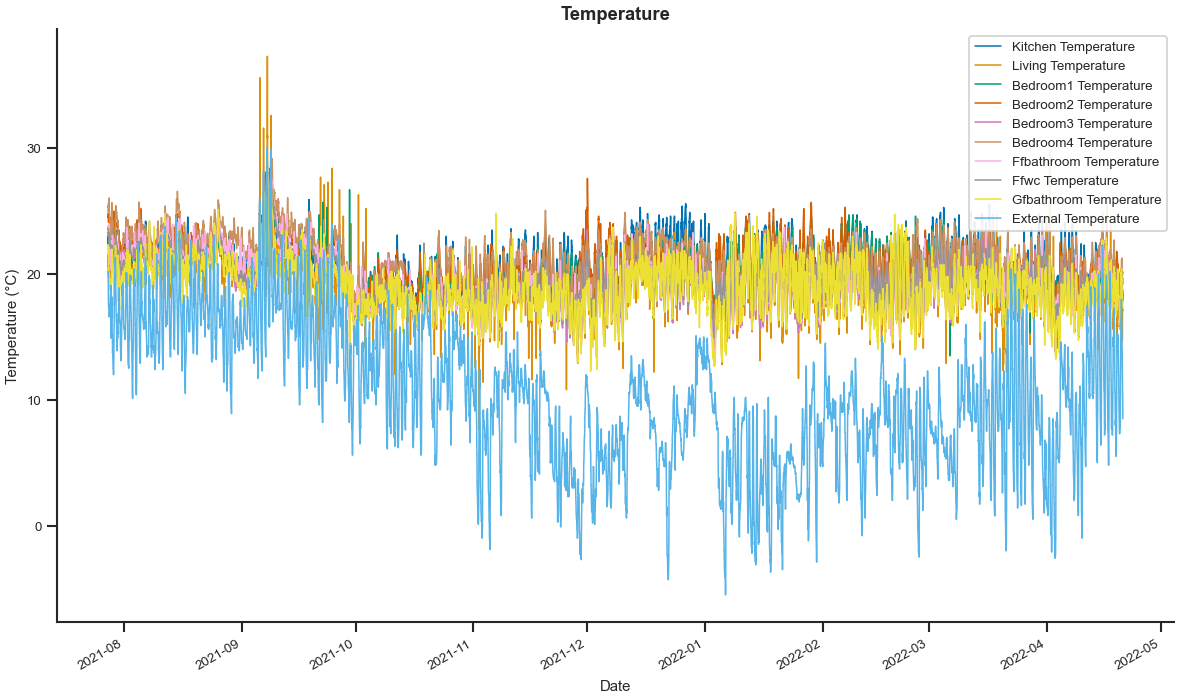

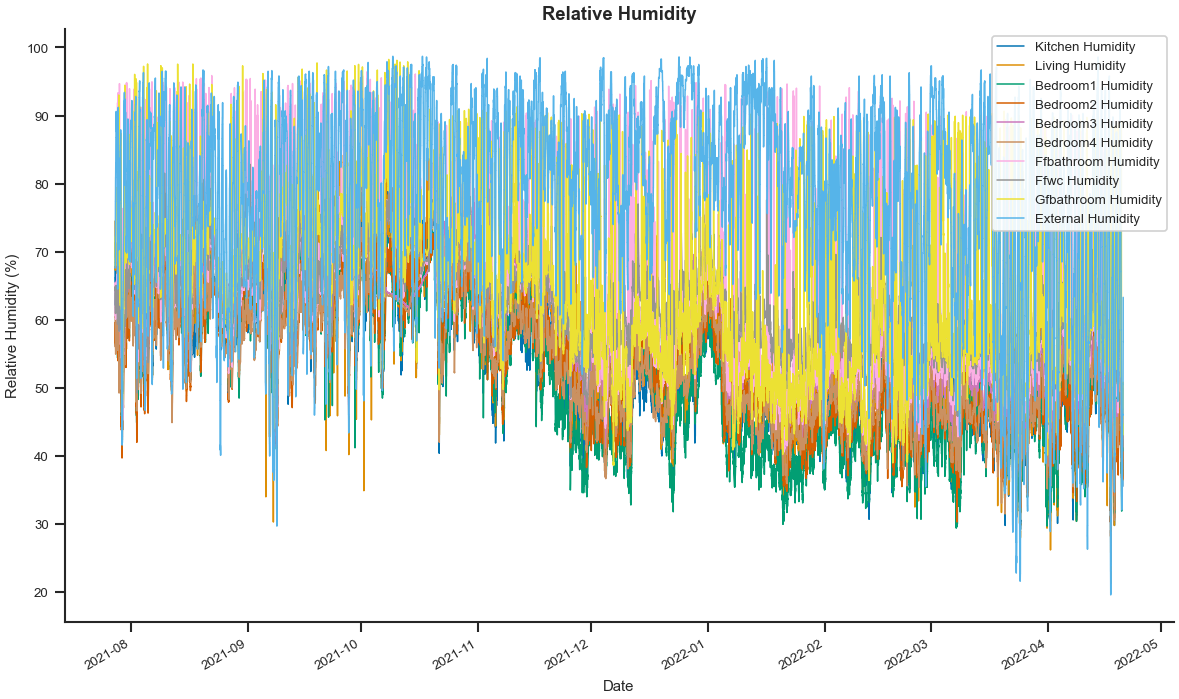

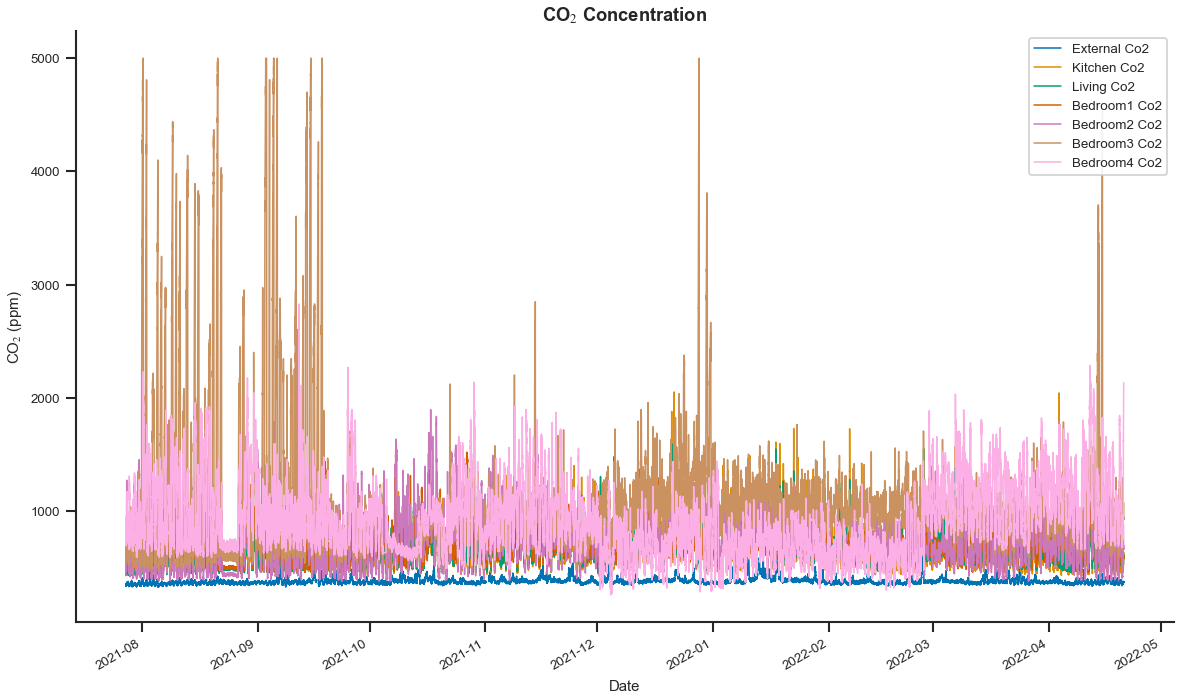

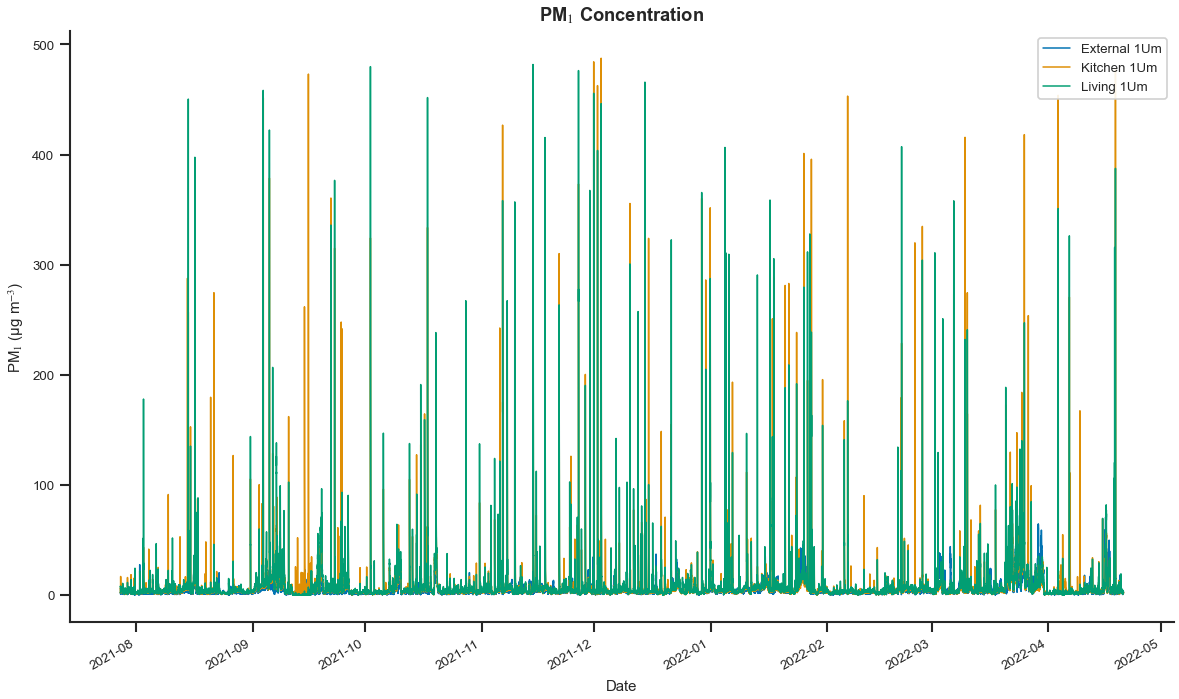

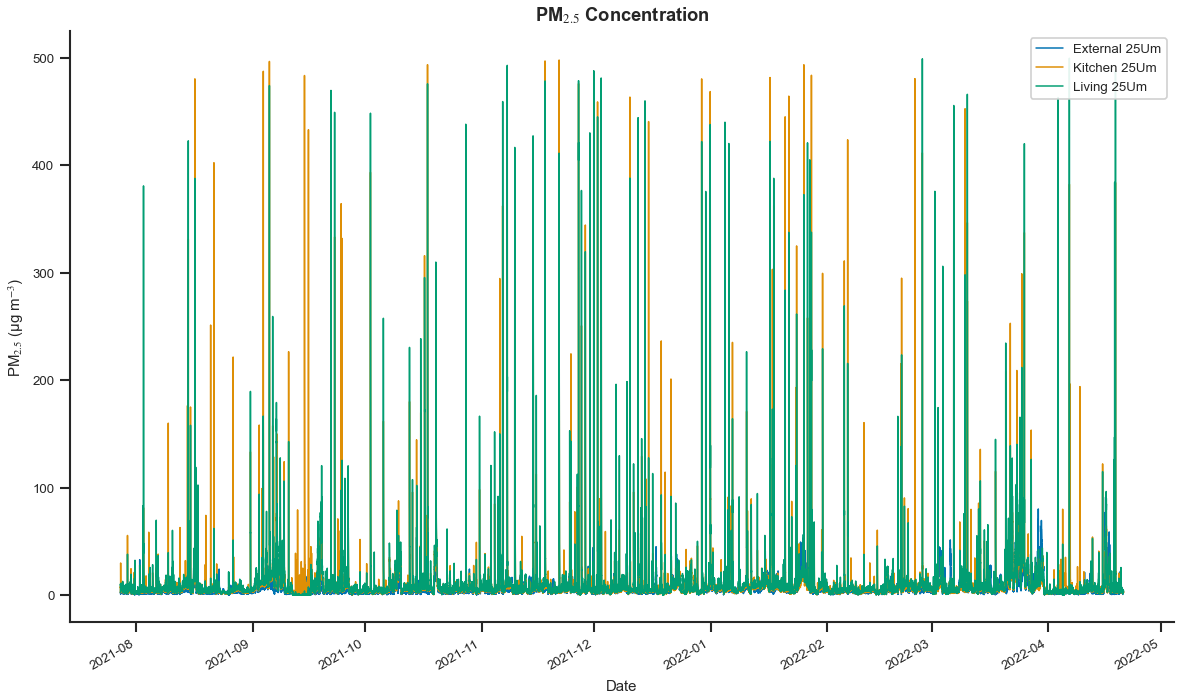

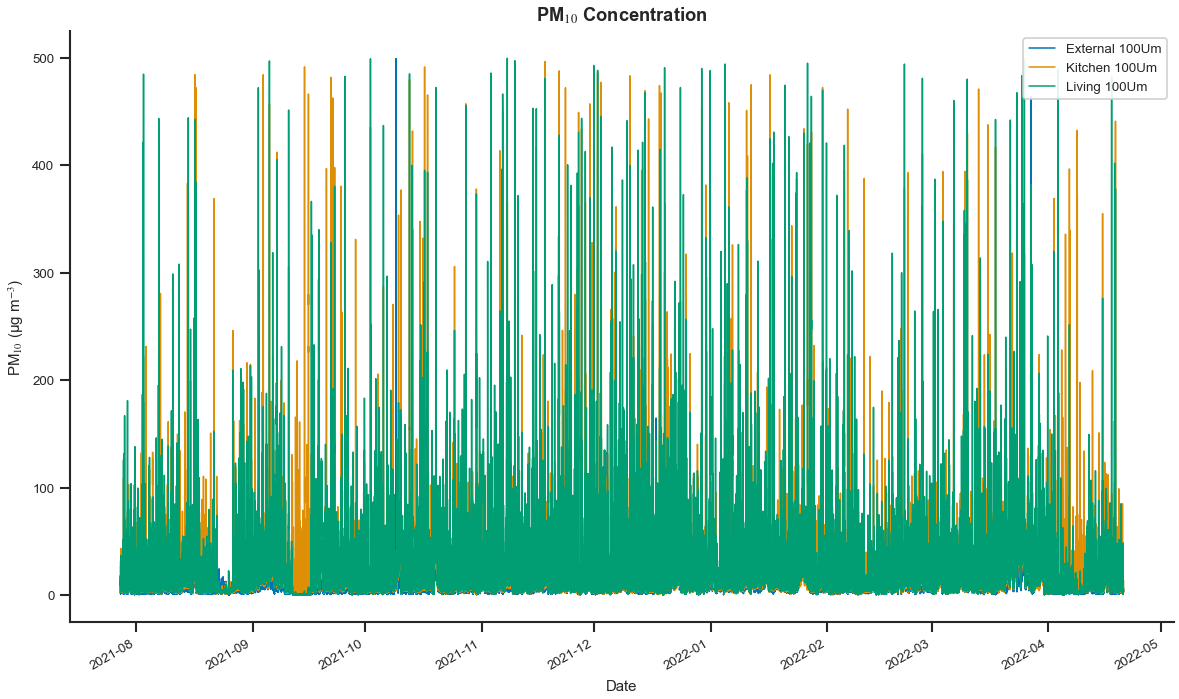

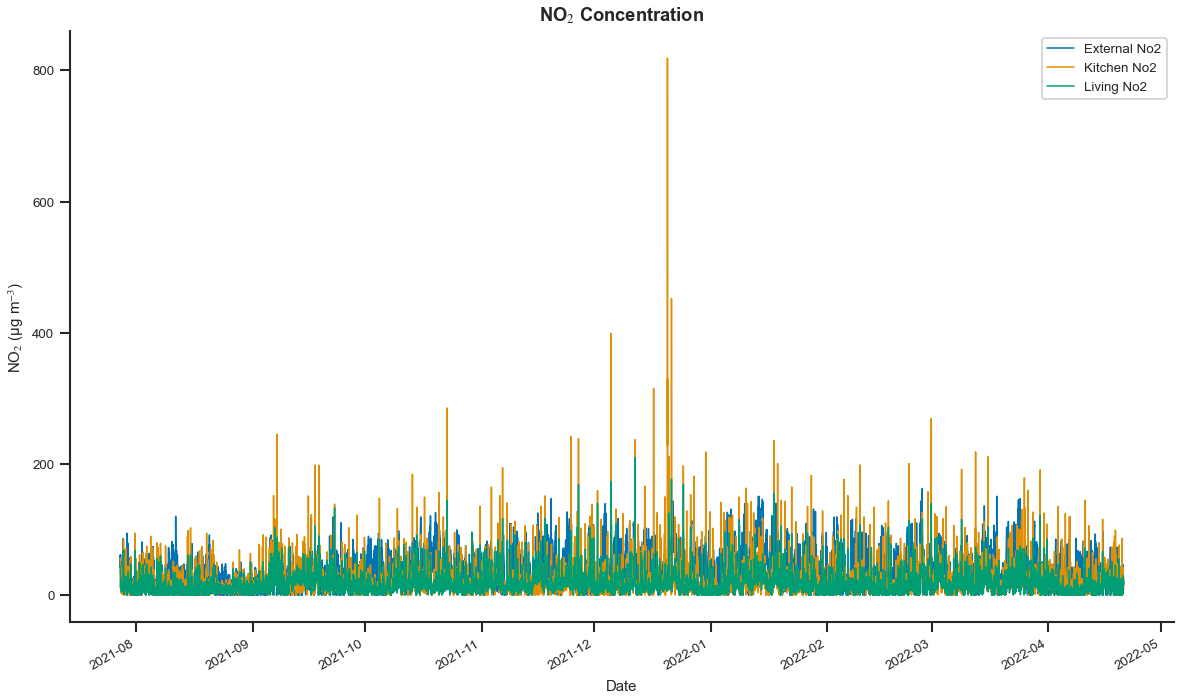

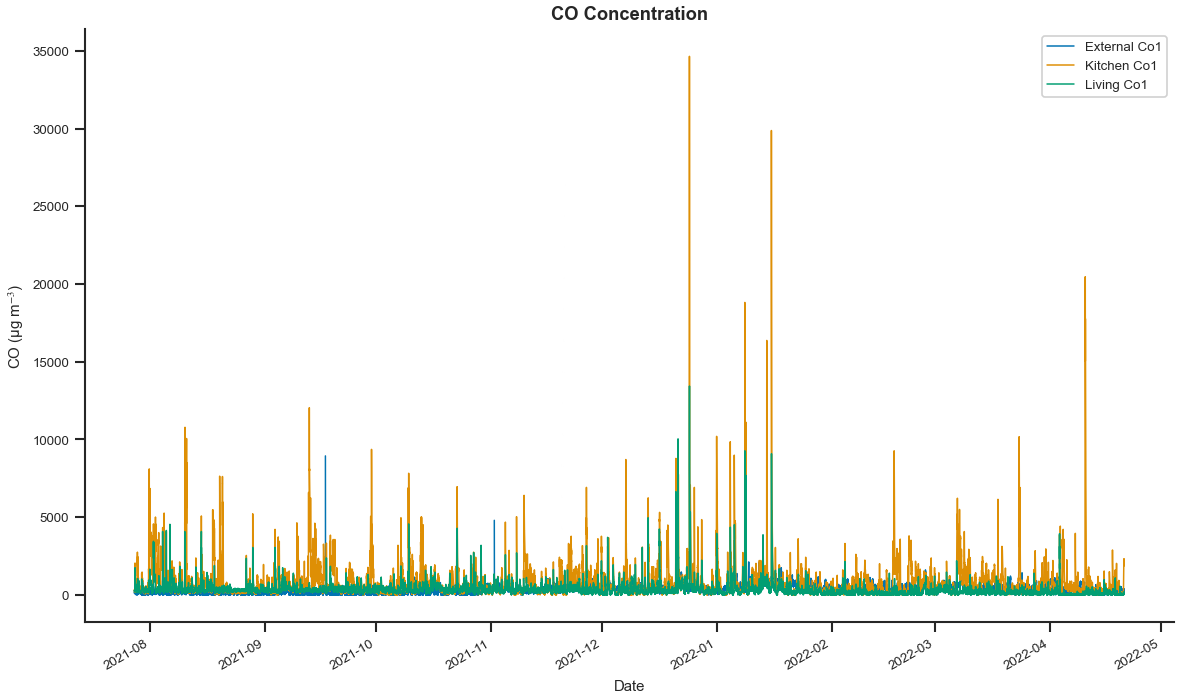

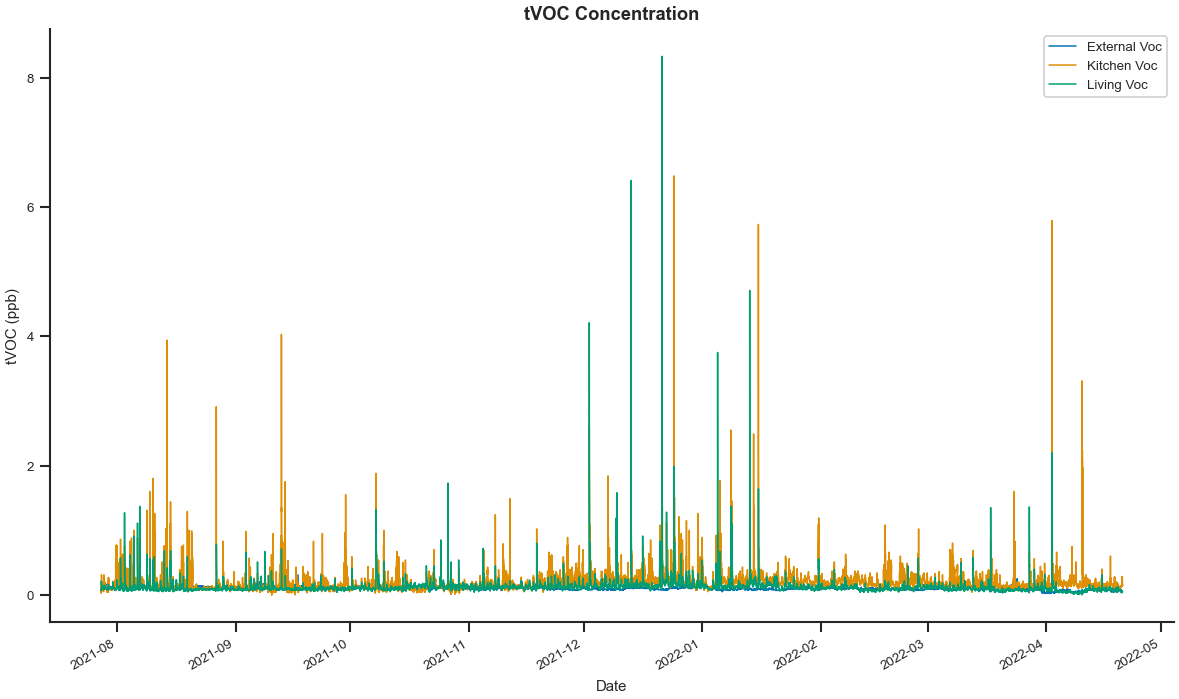

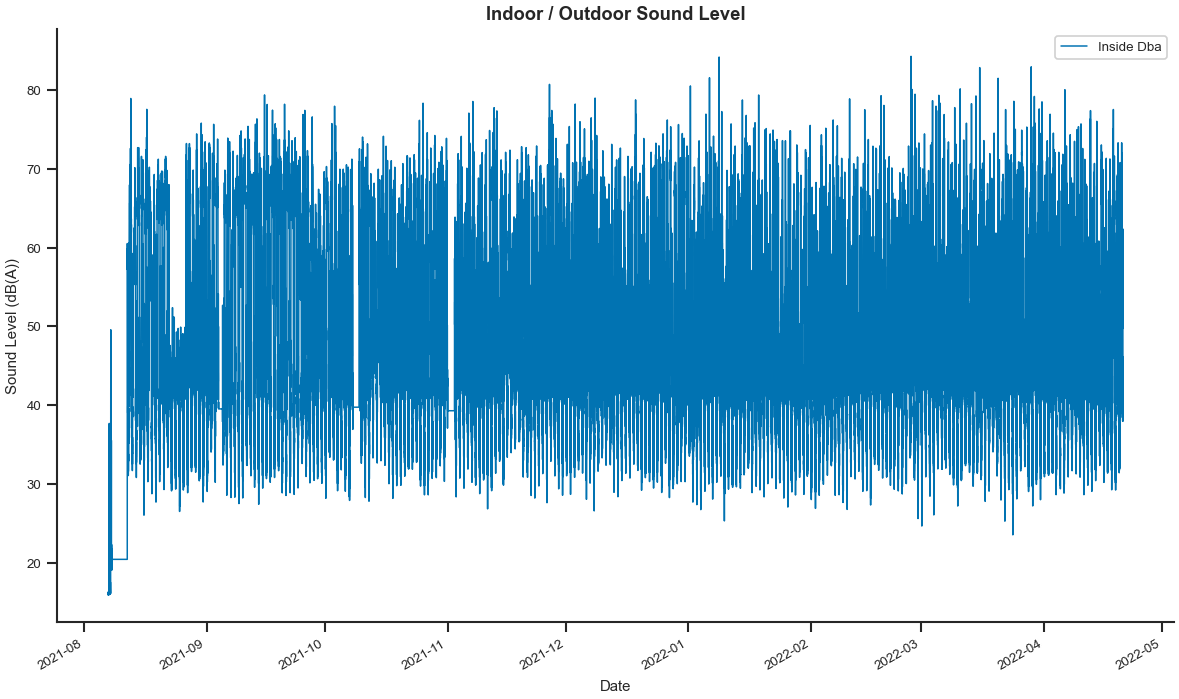

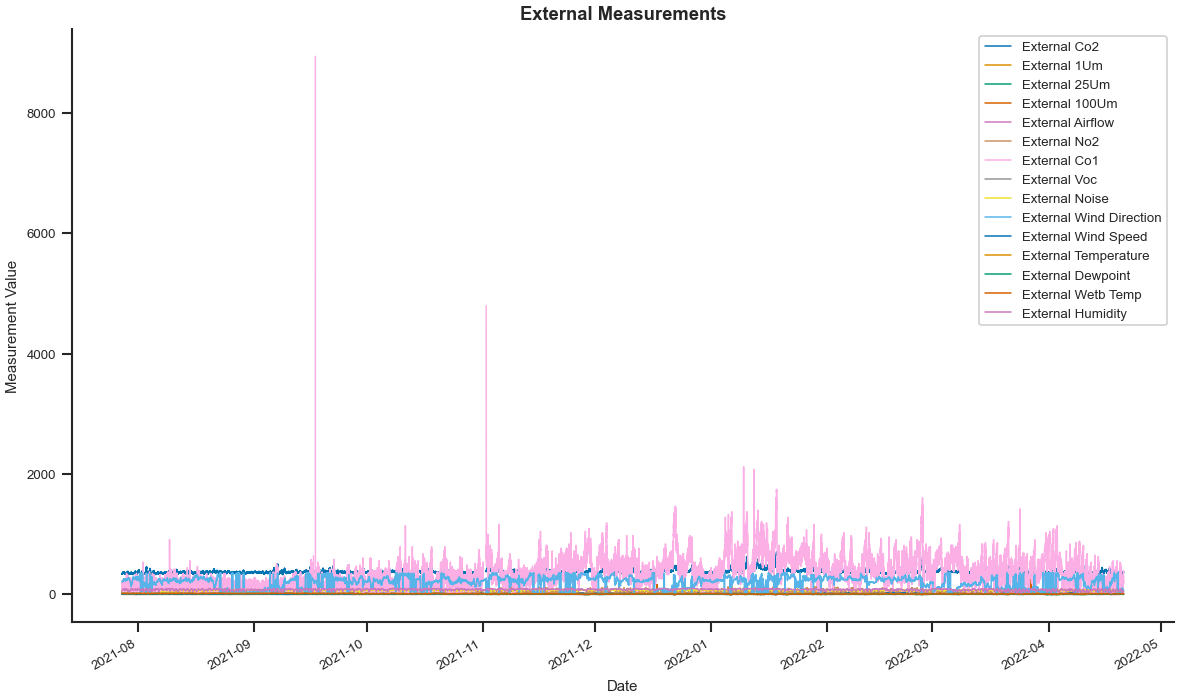

In [26]:
plot_grouped_variables(input_dataframe=p6, input_save=True, save_path="../data/p6_north_london_semi/plots/", figsize=(10, 6), dpi=300)

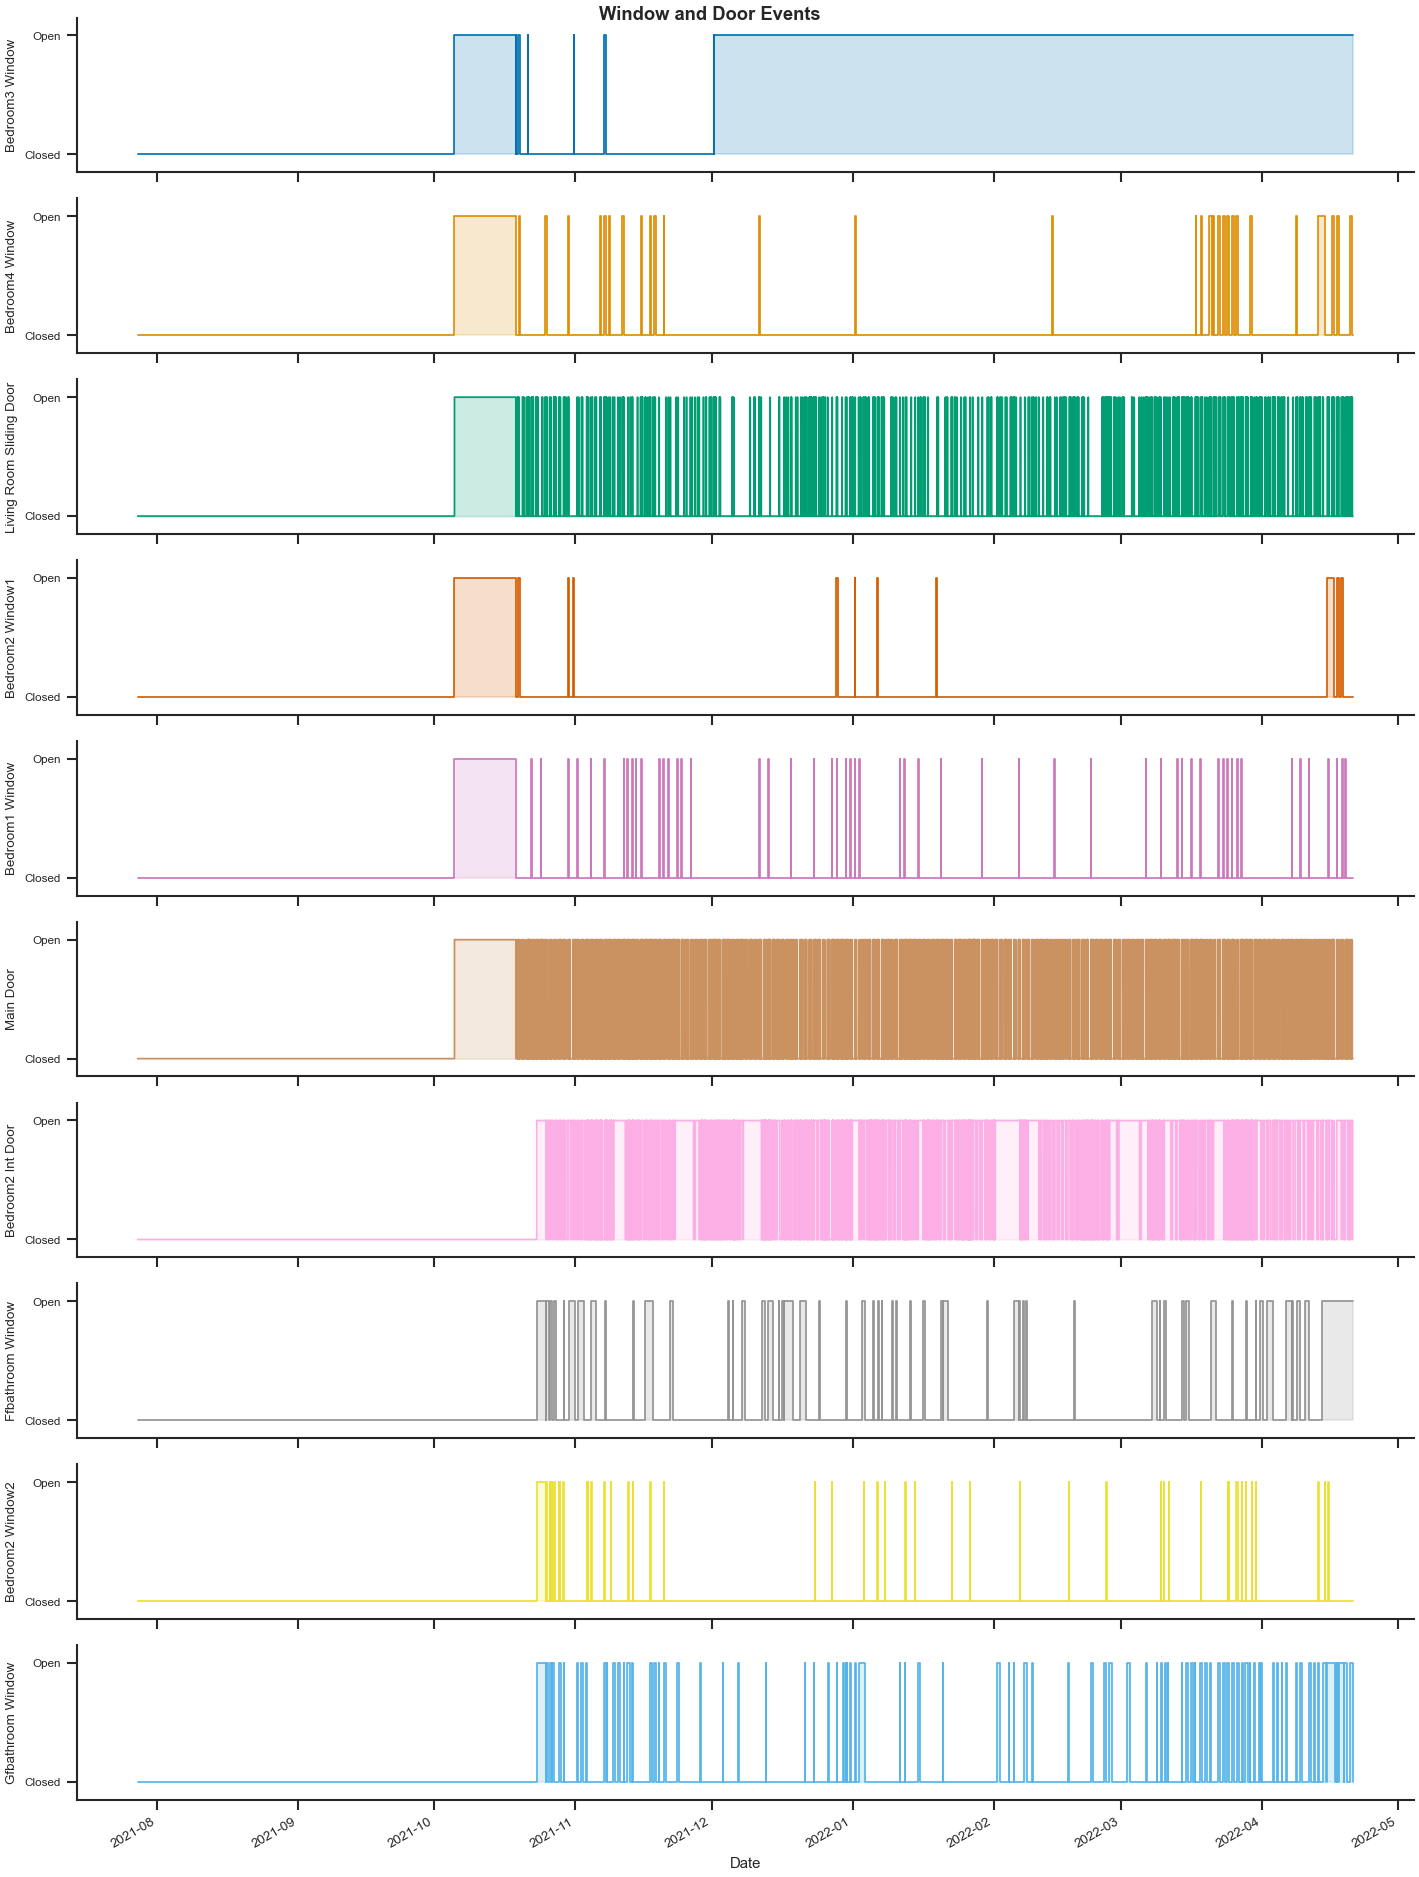

In [27]:
plot_event_timeseries(input_event_dict=p6_event_dict,
                      input_start_date=monitoring_start_date,
                      input_end_date=monitoring_end_date,
                      input_save=True,
                      save_path='../data/p6_north_london_semi/plots/')

## Summary Statistics

In [28]:
p6_continuous_stats, p6_event_stats = summary_statistics(
    input_dataframe=p6,
    input_rooms_and_variables=p6_rooms_and_variables,
    input_event_dict=p6_event_dict,
    input_rooms_and_events=p6_rooms_and_events
)

# Print the number of days of data collected
num_days = (p6.index[-1] - p6.index[0]).days
print(f"Number of days of data collected: {num_days} days")


====    Summary Statistics    ====

--- Continuous Variables ---

  bedroom3_temperature: n=76969, n_missing=0, mean=19.538, median=19.484
  bedroom3_humidity: n=76969, n_missing=0, mean=58.501, median=58.008
  bedroom3_co2: n=76969, n_missing=0, mean=1057.889, median=952.0
  external_co2: n=76605, n_missing=364, mean=379.416, median=373.0
  external_1um: n=69920, n_missing=7049, mean=4.322, median=2.24
  external_25um: n=69920, n_missing=7049, mean=5.526, median=3.22
  external_100um: n=69920, n_missing=7049, mean=6.398, median=3.826
  external_airflow: n=76605, n_missing=364, mean=3.556, median=3.56
  external_no2: n=76605, n_missing=364, mean=33.751, median=29.07
  external_co1: n=76605, n_missing=364, mean=320.625, median=279.408
  external_voc: n=76605, n_missing=364, mean=0.098, median=0.1
  external_noise: n=74017, n_missing=2952, mean=70.607, median=72.04
  external_wind_direction: n=76969, n_missing=0, mean=204.126, median=230.0
  external_wind_speed: n=76969, n_missing=0, me

## Save outputs

In [29]:
save_participant_outputs(
    n=6,
    df=p6,
    event_dict=p6_event_dict,
    rooms_and_variables=p6_rooms_and_variables,
    rooms_and_events=p6_rooms_and_events,
    rooms_list=p6_rooms_list,
    continuous_stats=p6_continuous_stats,
    event_stats=p6_event_stats,
data_dir='../data/p6_north_london_semi')

p6 outputs saved to ../data/p6_north_london_semi/data_processed/p6_outputs.pkl
